In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path=r"C:\Users\Rao\Documents\Naresh IT\DATA FILES\Visadataset.csv"
visa_df=pd.read_csv(file_path)

cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [218]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [220]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [130]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

- There are total 25480 applicants

- in those appplicants 17018 applicants got the visa

- also there are 16861 applicants applied for visa from Asia

- we want to know how many applicants from asia got certified

- and how many people from asia got denied


In [133]:
# step-1: select the continent data
#step2: continent data == 'Asia' it is con1
#step-3: select the case status data
#step-4: case status data == 'certified' in con2
#step5: con=con1&con2
#step-6: apply main df on con get the length

In [135]:
visa_df['continent']

0          Asia
1          Asia
2          Asia
3          Asia
4        Africa
          ...  
25475      Asia
25476      Asia
25477      Asia
25478      Asia
25479      Asia
Name: continent, Length: 25480, dtype: object

In [137]:
con1=visa_df['continent']=='Asia'

In [139]:

con2=visa_df['case_status']=='Certified'

con=con1&con2

len(visa_df[con])

11012

In [141]:
# from different countries how many people are certified
labels=visa_df['continent'].unique()
for i in labels:
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con=con1&con2
    print(len(visa_df[con]))

11012
397
2037
2957
493
122


In [144]:
labels=visa_df['continent'].unique()
cert_coun=[]
denied_count=[]
for i in labels:
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con3=visa_df['case_status']=='Denied'
    approved_con=con1&con2
    den_con= con1&con3
    cert_coun.append(len(visa_df[approved_con]))
    denied_count.append(len(visa_df[den_con]))
cols=sorted(visa_df['case_status'].unique())
pd.DataFrame(zip(cert_coun,den_con),
             columns=cols,index=labels)

,Certified,Denied
Asia,11012,False
Africa,397,False
North America,2037,False
Europe,2957,False
South America,493,False
Oceania,122,False


**cross tab**

In [147]:
#pd.crosstab(<index>,<columns>)
col1=visa_df['continent']
col2=visa_df['case_status']
r1=pd.crosstab(col1,col2)
r1

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


<Axes: xlabel='continent'>

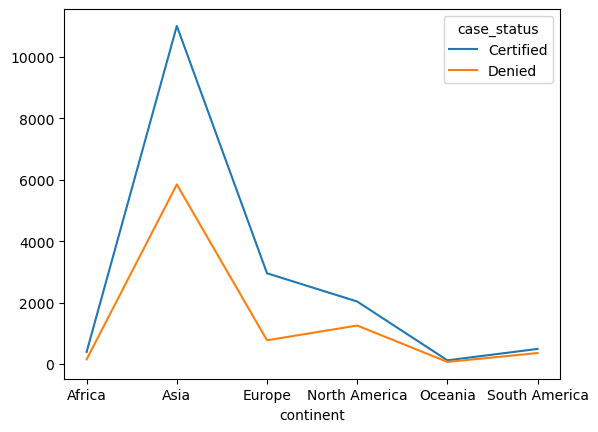

In [151]:
r1.plot()

<Axes: xlabel='continent'>

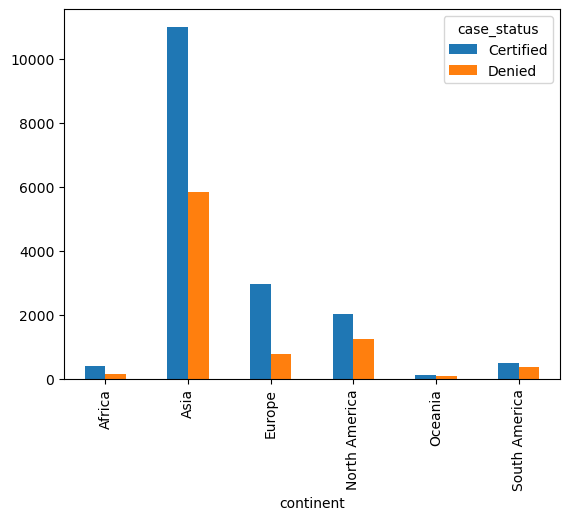

In [153]:
r1.plot(kind='bar')


**case status-continent-education_of_employee**

In [156]:
#from asia there are 16k applicamts applied for visa
# in that 11k+ ppl got certified
# in that 11k pppl different education applicants are available

# we wanr those information

In [158]:
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col3,col2]
r2=pd.crosstab(col1,cols)
r2

education_of_employee Bachelor's        Doctorate        High School         Master's       
case_status            Certified Denied Certified Denied   Certified Denied Certified Denied
continent                                                                                   
Africa                        81     62        43     11          23     43       250     38
Asia                        4407   2761       780    143         676   1614      5149   1331
Europe                      1040    259       788     58         162    328       967    130
North America                641    584       207     51         210    191       979    429
Oceania                       38     28        19      3          19     17        46     22
South America                160    173        75     14          74     63       184    109

<Axes: xlabel='continent'>

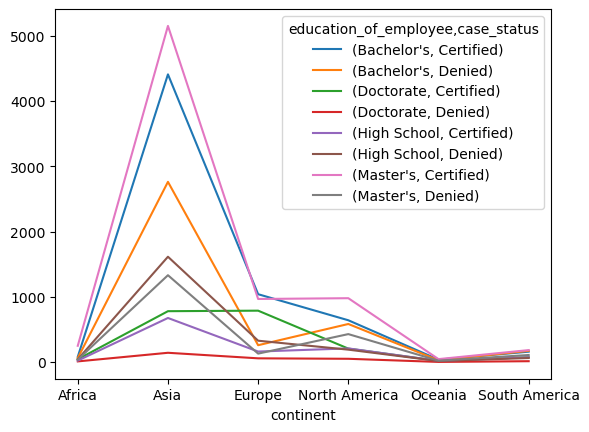

In [160]:
r2.plot()

In [162]:
visa_df['education_of_employee'].value_counts()

education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

In [164]:
visa_df['prevailing_wage']
#wages are numerical values
#25480 applicants are available
#different applicamts having the differnt wages

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [166]:
visa_df.groupby('education_of_employee')

In [168]:
list(visa_df.groupby('education_of_employee'))

[("Bachelor's",
           case_id      continent education_of_employee  ... unit_of_wage full_time_position  case_status
  2         EZYV03           Asia            Bachelor's  ...         Year                  Y       Denied
  3         EZYV04           Asia            Bachelor's  ...         Year                  Y       Denied
  6         EZYV07           Asia            Bachelor's  ...         Year                  Y    Certified
  7         EZYV08  North America            Bachelor's  ...         Hour                  Y       Denied
  8         EZYV09           Asia            Bachelor's  ...         Year                  Y    Certified
  ...          ...            ...                   ...  ...          ...                ...          ...
  25466  EZYV25467         Europe            Bachelor's  ...         Year                  Y       Denied
  25468  EZYV25469           Asia            Bachelor's  ...         Year                  N    Certified
  25473  EZYV25474           A

In [170]:
visa_df.groupby('education_of_employee').count()

,case_id,continent,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
education_of_employee,,,,,,,,,,,
Bachelor's,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234
Doctorate,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192
High School,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420
Master's,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634


In [172]:
visa_df.groupby('education_of_employee').size()


education_of_employee
Bachelor's     10234
Doctorate       2192
High School     3420
Master's        9634
dtype: int64

In [174]:
visa_df.groupby('education_of_employee')['prevailing_wage']


In [176]:
visa_df['prevailing_wage'].mean()
#mean wage of all 25480 observations
#Bachelors, Doctorates,HS,Masters

74455.81459209183

In [178]:
visa_df[visa_df['education_of_employee']=="Bachelor"]['prevailing_wage'].mean()

nan

In [180]:
visa_df.groupby('education_of_employee')['prevailing_wage'].mean()

education_of_employee
Bachelor's     73405.443735
Doctorate      64561.076657
High School    71582.147756
Master's       78843.057843
Name: prevailing_wage, dtype: float64

In [182]:
con=visa_df['case_status']=='Certified'
new_df=visa_df[con]
new_df.groupby('continent').size()

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [184]:
con=visa_df['case_status']=='Denied'
new_df=visa_df[con]
new_df.groupby('continent').size()

continent
Africa            154
Asia             5849
Europe            775
North America    1255
Oceania            70
South America     359
dtype: int64

In [188]:
# min wage of asia people
visa_df['prevailing_wage'].min()
visa_df.groupby('continent')['prevailing_wage'].min()

continent
Africa           32.9286
Asia              3.3188
Europe            9.1753
North America     2.1367
Oceania          24.4888
South America     3.0031
Name: prevailing_wage, dtype: float64

- we have seen continent and case status

- we have seen 3 variables continent, case status and education of employees

- we have done similar analysois using group by

- only categorical column analysis completed

- only numerical column analysis completed

- Also Bi variate and multivariate analysis alsp completed

- Now we need to perform Two numerical column analysis

    - This will give relation between two columns which are numerical in nature
    - so we can perform correlation matrix to get the relationship
    - so we need to perform scatter plot to visualize relation


**plt.scatter**

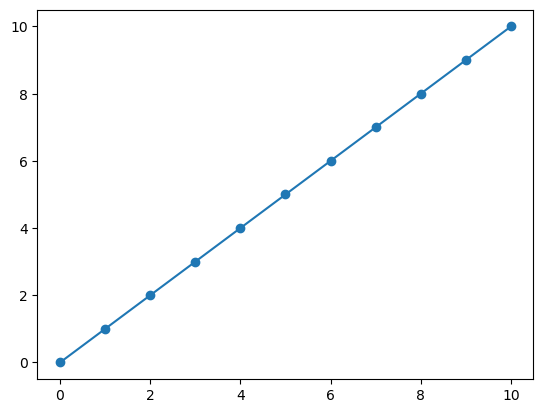

In [196]:
x=range(0,11)
y=range(0,11)
plt.scatter(x,y)
plt.plot(x,y)

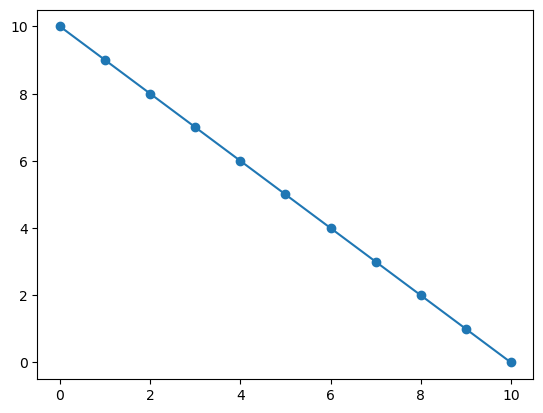

In [208]:
x=range(0,11)
y=range(10,-1,-1)
plt.scatter(x,y)
plt.plot(x,y)

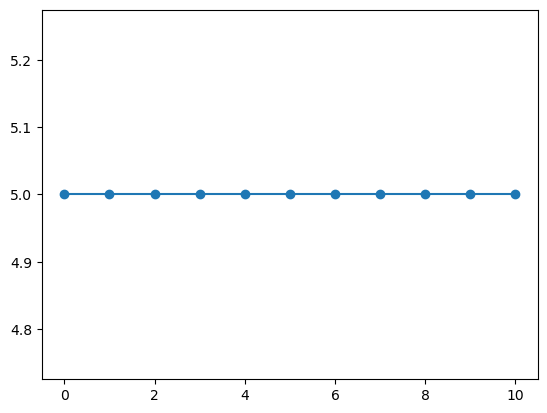

In [206]:
x=range(0,11)
y=[5 for i in range(0,11)]
plt.scatter(x,y)
plt.plot(x,y)

In [210]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [222]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [242]:
visa_df.corr(numeric_only=True)


,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


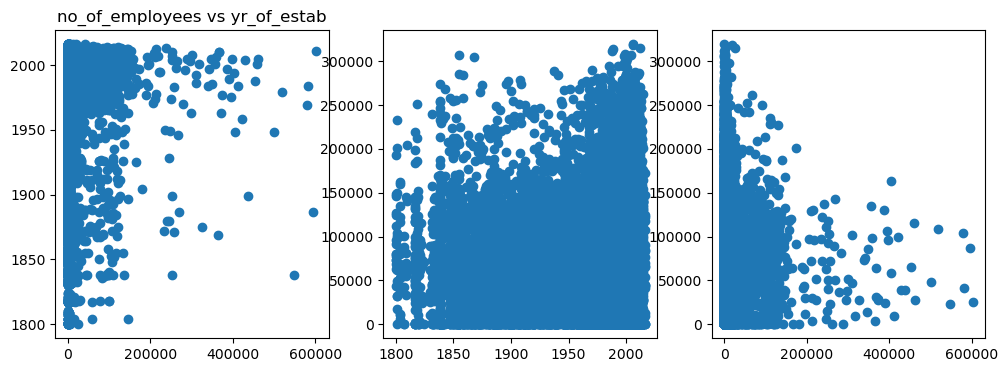

In [244]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(12,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.title('no_of_employees vs yr_of_estab')
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)

In [248]:
path=r"C:\Users\Rao\Documents\Naresh IT\DATA FILES\winequality_red.csv"
wine_qual = pd.read_csv(path)
wine_qual.corr(numeric_only=True)
wine_qual

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [250]:
wine_qual.max()

fixed acidity            15.90000
volatile acidity          1.58000
citric acid               1.00000
residual sugar           15.50000
chlorides                 0.61100
free sulfur dioxide      72.00000
total sulfur dioxide    289.00000
density                   1.00369
pH                        4.01000
sulphates                 2.00000
alcohol                  14.90000
quality                   8.00000
dtype: float64

**heat map**

- any matrix values we can visualize using a heatmap

- it will provide colours for differenet values

- heatmap also provides color bars which indicates the colour and its values

- For example the values range from 0.8 to 1 display in blue

- so we no need to check values, we can directly see the blue colour

- so immediately we can sense bluecolour means ighest values which is 0.8 to 1

- heat map available in sea born


<Axes: >

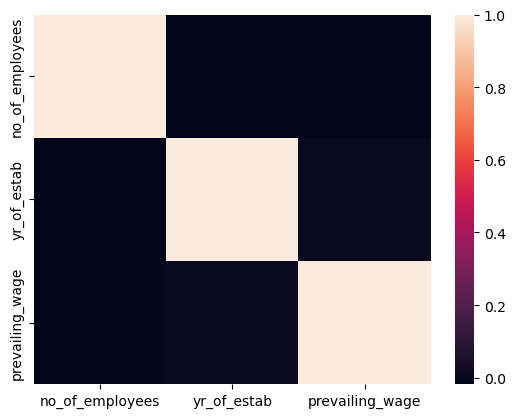

In [262]:
visa_corr=visa_df.corr(numeric_only=True)

sns.heatmap(visa_corr)

<Axes: >

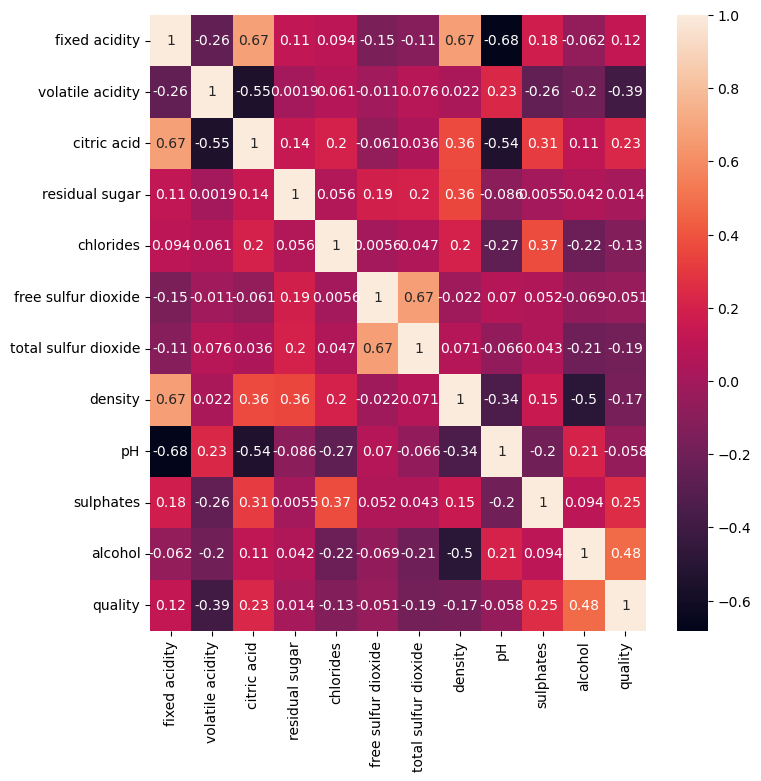

In [264]:
wine_corr= wine_qual.corr(numeric_only=True)
plt.figure(figsize=(8,8))
sns.heatmap(wine_corr,annot=True)

In [266]:
wine_qual.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

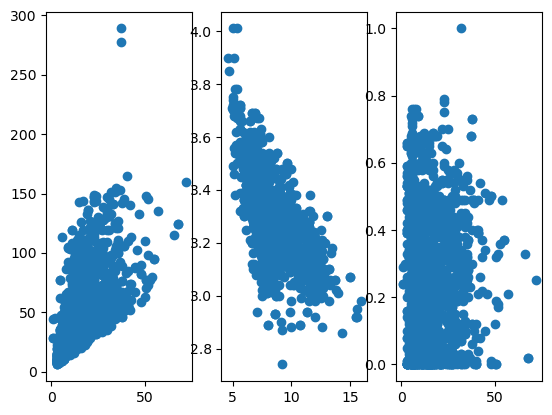

In [270]:
col1=wine_qual['free sulfur dioxide']
col2=wine_qual['total sulfur dioxide']
col3=wine_qual['fixed acidity']
col4=wine_qual['pH']
col5=wine_qual['citric acid']
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col3,col4)
plt.subplot(1,3,3).scatter(col1,col5)